In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [174]:
gdp = pd.read_csv('gdp_per_capital.csv')
gdp = gdp.drop(columns=['Indicator Name'])

maternal = pd.read_excel('SH_STA_MORT.xlsx')
maternal = maternal.drop(columns=['Goal', 'Target', 'Indicator', 'SeriesCode', 'SeriesDescription', 'GeoAreaCode', 'Age', 'Freq', 'Location', 'Reporting Type', 'Sex', 'Units'])

infant = pd.read_excel('SH_DYN_IMRT (1).xlsx')
infant = infant.drop(columns=['Goal', 'Target', 'Indicator', 'SeriesCode', 'SeriesDescription', 'GeoAreaCode', 'Reporting Type', 'Units'])
infant = infant[infant['Sex'] == 'BOTHSEX']

birth = pd.read_csv("average-age-of-having-first-child-by-country-2025.csv")
birth = birth.drop(columns=['flagCode', 'AverageAgeOfHavingFirstChild_CIADataYear'])
birth = birth.rename(columns={"country": "Country Name", 'AverageAgeOfHavingFirstChild_CIA': 'average_first_child_age'})

health = pd.read_excel("SH_STA_BRTC.xlsx")
health = health.drop(columns=['Goal', 'Target', 'Indicator', 'SeriesCode', 'SeriesDescription', 'GeoAreaCode', 'Observation Status', 'Reporting Type', 'Units'])
health = health.rename(columns={"GeoAreaName": "Country Name"})
#birth = pd.read_csv("average_first_child.csv")
#birth = birth.drop(columns=['Code'])
#birth = birth.rename(columns={"Entity": "Country Name", "Mean age at childbearing, historical": "average_childbearing_age"})
#birth["Year"] = birth["Year"].astype(str)

# gdp: Annual growth rate of real GDP per capita (%)
# maternal: Maternal mortality ratio (modeled estimate, per 100,000 live births)
# infant: measures Infant mortality rate (deaths per 1,000 live births), units is per 1000 live births
# birth: average childbearing age, historically

In [175]:
# Convert datasets from wide to long

years_now = ['2000', '2001', '2002', '2003', '2004', '2005', '2006',
       '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
       '2016', '2017', '2018', '2019', '2020']
maternal_long = pd.melt(maternal, id_vars=['GeoAreaName'], 
                  value_vars=years_now,
                  var_name='Year', 
                  value_name='maternal_mortality_ratio')
countries_mat = list(maternal_long['GeoAreaName'].unique())

gdp_long = pd.melt(gdp, id_vars=['Country Name'],
                   value_vars=years_now,
                   var_name='Year',
                   value_name='gdp_per_capita_(usd)')

infant_long = pd.melt(infant, id_vars=['GeoAreaName'], 
                  value_vars=years_now,
                  var_name='Year', 
                  value_name='infant_mortality_rate')
countries_infant = list(infant_long['GeoAreaName'].unique())

infant_long = infant_long.rename(columns={'GeoAreaName': "Country Name"})
maternal_long = maternal_long.rename(columns={'GeoAreaName': "Country Name"})

countries_long = pd.merge(infant_long, maternal_long, on=['Country Name', 'Year'], how='left')

health_long = pd.melt(health, id_vars=['Country Name'],
                      value_vars=years_now,
                      var_name='Year',
                      value_name='births_attended_by_skilled_professionals')
health_2019 = health_long[health_long['Year'] == '2019'].drop(columns=['Year'])

In [176]:
#set(list(countries_long['Country Name'].unique())) - set(list(gdp_long['Country Name'].unique()))

In [177]:
#set(list(gdp_long['Country Name'].unique())) - set(list(countries_long['Country Name'].unique()))

In [178]:
name_map = {
    "Bolivia": "Bolivia (Plurinational State of)",
    "Brunei": "Brunei Darussalam",
    "Cape Verde": "Cabo Verde",
    "Congo, Dem. Rep.": "Democratic Republic of the Congo",
    "Congo, Rep.": "Congo",
    "Czech Republic": "Czechia",
    "East Timor": "Timor-Leste",
    "Ethiopia(excludes Eritrea)": "Ethiopia",
    "Moldova": "Republic of Moldova",
    "Netherlands": "Netherlands (Kingdom of the)",
    "Russia": "Russian Federation",
    "São Tomé and Príncipe": "Sao Tome and Principe",
    "Tanzania": "United Republic of Tanzania",
    "Turkey": "Türkiye",
    "United Kingdom": "United Kingdom of Great Britain and Northern Ireland",
    "Venezuela": "Venezuela (Bolivarian Republic of)",
    "Vietnam": "Viet Nam"
}

gdp_long["Country Name"] = gdp_long["Country Name"].replace(name_map)


In [179]:
#set(list(countries_long['Country Name'].unique())) - set(list(birth['Country Name'].unique()))

In [180]:
#set(list(birth['Country Name'].unique())) - set(list(countries_long['Country Name'].unique()))

In [181]:
'''name_map = {
    "Bolivia": "Bolivia (Plurinational State of)",
    "Brunei": "Brunei Darussalam",
    "Cape Verde": "Cabo Verde",
    "Cote d'Ivoire": "Côte d'Ivoire",
    "Democratic Republic of Congo": "Democratic Republic of the Congo",
    "East Timor": "Timor-Leste",
    "Iran": "Iran (Islamic Republic of)",
    "Laos": "Lao People's Democratic Republic",
    "Micronesia (country)": "Micronesia (Federated States of)",
    "Moldova": "Republic of Moldova",
    "Netherlands": "Netherlands (Kingdom of the)",
    "North Korea": "Democratic People's Republic of Korea",
    "Palestine": "State of Palestine",
    "Russia": "Russian Federation",
    "South Korea": "Republic of Korea",
    "Syria": "Syrian Arab Republic",
    "Tanzania": "United Republic of Tanzania",
    "Turkey": "Türkiye",
    "United Kingdom": "United Kingdom of Great Britain and Northern Ireland",
    "United States": "United States of America",
    "Venezuela": "Venezuela (Bolivarian Republic of)",
    "Vietnam": "Viet Nam"
}
birth["Country Name"] = birth["Country Name"].replace(name_map)'''

'name_map = {\n    "Bolivia": "Bolivia (Plurinational State of)",\n    "Brunei": "Brunei Darussalam",\n    "Cape Verde": "Cabo Verde",\n    "Cote d\'Ivoire": "Côte d\'Ivoire",\n    "Democratic Republic of Congo": "Democratic Republic of the Congo",\n    "East Timor": "Timor-Leste",\n    "Iran": "Iran (Islamic Republic of)",\n    "Laos": "Lao People\'s Democratic Republic",\n    "Micronesia (country)": "Micronesia (Federated States of)",\n    "Moldova": "Republic of Moldova",\n    "Netherlands": "Netherlands (Kingdom of the)",\n    "North Korea": "Democratic People\'s Republic of Korea",\n    "Palestine": "State of Palestine",\n    "Russia": "Russian Federation",\n    "South Korea": "Republic of Korea",\n    "Syria": "Syrian Arab Republic",\n    "Tanzania": "United Republic of Tanzania",\n    "Turkey": "Türkiye",\n    "United Kingdom": "United Kingdom of Great Britain and Northern Ireland",\n    "United States": "United States of America",\n    "Venezuela": "Venezuela (Bolivarian Republ

In [182]:
name_mapping = {
    'Bolivia (Plurinational State of)': 'Bolivia',
    'Czechia': 'Czech Republic',
    'Democratic Republic of the Congo': 'DR Congo',
    "Côte d'Ivoire": 'Ivory Coast',
    'Republic of Korea': 'South Korea',
    'United Republic of Tanzania': 'Tanzania',
    'Türkiye': 'Turkey',
    'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
    'Russian Federation': 'Russia',
    'Republic of Moldova': 'Moldova',
    'Micronesia (Federated States of)': 'Micronesia',
    'Netherlands (Kingdom of the)': 'Netherlands',
    'Republic of the Congo': 'Republic of the Congo',  # matches both ways
    "Democratic People's Republic of Korea": 'North Korea'  # optional
    # Add more if needed
}
birth['Country Name'] = birth['Country Name'].replace(name_mapping)


In [183]:
df = pd.merge(countries_long, gdp_long, on=['Country Name', 'Year'], how='left')
#df = pd.merge(df, birth, on=['Country Name', 'Year'], how='left')

In [184]:
df_2019 = df[df['Year'] == '2019']

In [185]:
df_2019 = pd.merge(df_2019, birth, on=['Country Name'], how='left')

In [187]:
df_2019 = pd.merge(df_2019, health_2019, on=['Country Name'], how='left')

In [201]:
country_to_continent = {
    'Afghanistan': 'Asia',
    'Albania': 'Europe',
    'Algeria': 'Africa',
    'Angola': 'Africa',
    'Antigua and Barbuda': 'North America',
    'Argentina': 'South America',
    'Armenia': 'Asia',
    'Australia': 'Oceania',
    'Austria': 'Europe',
    'Azerbaijan': 'Asia',
    'Bahamas': 'North America',
    'Bahrain': 'Asia',
    'Bangladesh': 'Asia',
    'Barbados': 'North America',
    'Belarus': 'Europe',
    'Belgium': 'Europe',
    'Belize': 'North America',
    'Benin': 'Africa',
    'Bhutan': 'Asia',
    'Bolivia (Plurinational State of)': 'South America',
    'Bosnia and Herzegovina': 'Europe',
    'Botswana': 'Africa',
    'Brazil': 'South America',
    'Brunei Darussalam': 'Asia',
    'Bulgaria': 'Europe',
    'Burkina Faso': 'Africa',
    'Burundi': 'Africa',
    'Cabo Verde': 'Africa',
    'Cambodia': 'Asia',
    'Cameroon': 'Africa',
    'Canada': 'North America',
    'Central African Republic': 'Africa',
    'Chad': 'Africa',
    'Chile': 'South America',
    'China': 'Asia',
    'Colombia': 'South America',
    'Comoros': 'Africa',
    'Congo': 'Africa',
    'Costa Rica': 'North America',
    "Côte d'Ivoire": 'Africa',
    'Croatia': 'Europe',
    'Cuba': 'North America',
    'Cyprus': 'Asia',
    'Czechia': 'Europe',
    "Democratic People's Republic of Korea": 'Asia',
    'Democratic Republic of the Congo': 'Africa',
    'Denmark': 'Europe',
    'Djibouti': 'Africa',
    'Dominican Republic': 'North America',
    'Ecuador': 'South America',
    'Egypt': 'Africa',
    'El Salvador': 'North America',
    'Equatorial Guinea': 'Africa',
    'Eritrea': 'Africa',
    'Estonia': 'Europe',
    'Eswatini': 'Africa',
    'Ethiopia': 'Africa',
    'Fiji': 'Oceania',
    'Finland': 'Europe',
    'France': 'Europe',
    'Gabon': 'Africa',
    'Gambia': 'Africa',
    'Georgia': 'Asia',
    'Germany': 'Europe',
    'Ghana': 'Africa',
    'Greece': 'Europe',
    'Grenada': 'North America',
    'Guatemala': 'North America',
    'Guinea': 'Africa',
    'Guinea-Bissau': 'Africa',
    'Guyana': 'South America',
    'Haiti': 'North America',
    'Honduras': 'North America',
    'Hungary': 'Europe',
    'Iceland': 'Europe',
    'India': 'Asia',
    'Indonesia': 'Asia',
    'Iran (Islamic Republic of)': 'Asia',
    'Iraq': 'Asia',
    'Ireland': 'Europe',
    'Israel': 'Asia',
    'Italy': 'Europe',
    'Jamaica': 'North America',
    'Japan': 'Asia',
    'Jordan': 'Asia',
    'Kazakhstan': 'Asia',
    'Kenya': 'Africa',
    'Kiribati': 'Oceania',
    'Kuwait': 'Asia',
    'Kyrgyzstan': 'Asia',
    "Lao People's Democratic Republic": 'Asia',
    'Latvia': 'Europe',
    'Lebanon': 'Asia',
    'Lesotho': 'Africa',
    'Liberia': 'Africa',
    'Libya': 'Africa',
    'Lithuania': 'Europe',
    'Luxembourg': 'Europe',
    'Madagascar': 'Africa',
    'Malawi': 'Africa',
    'Malaysia': 'Asia',
    'Maldives': 'Asia',
    'Mali': 'Africa',
    'Malta': 'Europe',
    'Mauritania': 'Africa',
    'Mauritius': 'Africa',
    'Mexico': 'North America',
    'Micronesia (Federated States of)': 'Oceania',
    'Mongolia': 'Asia',
    'Montenegro': 'Europe',
    'Morocco': 'Africa',
    'Mozambique': 'Africa',
    'Myanmar': 'Asia',
    'Namibia': 'Africa',
    'Nepal': 'Asia',
    'Netherlands (Kingdom of the)': 'Europe',
    'New Zealand': 'Oceania',
    'Nicaragua': 'North America',
    'Niger': 'Africa',
    'Nigeria': 'Africa',
    'North Macedonia': 'Europe',
    'Norway': 'Europe',
    'Oman': 'Asia',
    'Pakistan': 'Asia',
    'Panama': 'North America',
    'Papua New Guinea': 'Oceania',
    'Paraguay': 'South America',
    'Peru': 'South America',
    'Philippines': 'Asia',
    'Poland': 'Europe',
    'Portugal': 'Europe',
    'Qatar': 'Asia',
    'Republic of Korea': 'Asia',
    'Republic of Moldova': 'Europe',
    'Romania': 'Europe',
    'Russian Federation': 'Europe',
    'Rwanda': 'Africa',
    'Saint Lucia': 'North America',
    'Saint Vincent and the Grenadines': 'North America',
    'Samoa': 'Oceania',
    'Sao Tome and Principe': 'Africa',
    'Saudi Arabia': 'Asia',
    'Senegal': 'Africa',
    'Serbia': 'Europe',
    'Seychelles': 'Africa',
    'Sierra Leone': 'Africa',
    'Singapore': 'Asia',
    'Slovakia': 'Europe',
    'Slovenia': 'Europe',
    'Solomon Islands': 'Oceania',
    'Somalia': 'Africa',
    'South Africa': 'Africa',
    'South Sudan': 'Africa',
    'Spain': 'Europe',
    'Sri Lanka': 'Asia',
    'State of Palestine': 'Asia',
    'Sudan': 'Africa',
    'Suriname': 'South America',
    'Sweden': 'Europe',
    'Switzerland': 'Europe',
    'Syrian Arab Republic': 'Asia',
    'Tajikistan': 'Asia',
    'Thailand': 'Asia',
    'Timor-Leste': 'Asia',
    'Togo': 'Africa',
    'Tonga': 'Oceania',
    'Trinidad and Tobago': 'North America',
    'Tunisia': 'Africa',
    'Türkiye': 'Asia',
    'Turkmenistan': 'Asia',
    'Uganda': 'Africa',
    'Ukraine': 'Europe',
    'United Arab Emirates': 'Asia',
    'United Kingdom of Great Britain and Northern Ireland': 'Europe',
    'United Republic of Tanzania': 'Africa',
    'United States of America': 'North America',
    'Uruguay': 'South America',
    'Uzbekistan': 'Asia',
    'Vanuatu': 'Oceania',
    'Venezuela (Bolivarian Republic of)': 'South America',
    'Viet Nam': 'Asia',
    'Yemen': 'Asia',
    'Zambia': 'Africa',
    'Zimbabwe': 'Africa'
}
df_2019['Continent'] = df_2019['Country Name'].map(country_to_continent)
df_2019

,Country Name,Year,infant_mortality_rate,maternal_mortality_ratio,gdp_per_capita_(usd),average_first_child_age,births_attended_by_skilled_professionals,Continent
0,Afghanistan,2019,56.9,644.27255,500.522981,19.9,NaN,Asia
1,Albania,2019,8.0,5.30502,5396.214227,26.6,NaN,Europe
2,Algeria,2019,20.7,76.71434,4021.983608,NaN,98.8,Africa
3,Angola,2019,43.8,227.68696,2142.238757,19.4,NaN,Africa
4,Antigua and Barbuda,2019,8.0,18.91320,18187.779712,NaN,NaN,North America
...,...,...,...,...,...,...,...,...
214,Western Europe,2019,3.3,5.83009,NaN,NaN,97.4,NaN
215,World,2019,28.9,225.23515,NaN,NaN,83.3,NaN
216,Yemen,2019,38.8,181.33215,693.816484,20.8,NaN,Asia
217,Zambia,2019,35.7,128.84006,1268.120941,19.2,80.4,Africa


In [207]:
df_2019.to_csv("2019_stats.csv")

In [206]:
# Assuming your DataFrame is named df
# Drop rows with missing average_first_child_age
filtered_df = df_2019.dropna(subset=['average_first_child_age'])

# Sort by average_first_child_age ascending and take top 5
lowest_birth_age_df = filtered_df.sort_values(by='average_first_child_age').head(10)

# Display the result
lowest_birth_age_df.to_csv("top10_lowest_childbirth.csv")


In [ ]:
manual_updates = {
    'Niger': 39.1,
    'Liberia': 84.4,
    'Malawi': 60.0
}

for country, value in manual_updates.items():
    df.loc[df['Country Name'] == country, 'births_attended_by_skilled_professionals'] = value


In [191]:
'''# Assuming df is already loaded
# Drop rows with NaNs in any relevant columns for plotting and correlation
plot_df = df.dropna(subset=[
    "infant_mortality_rate",
    "maternal_mortality_ratio",
    "gdp_per_capita_(usd)",
    "average_childbearing_age"
])

# Set seaborn style
sns.set(style="whitegrid")

# Plot 1: Infant Mortality Rate vs GDP per Capita
plt.figure(figsize=(7, 5))
sns.scatterplot(data=plot_df, x="gdp_per_capita_(usd)", y="infant_mortality_rate")
plt.title("Infant Mortality Rate vs GDP per Capita")
plt.xlabel("GDP per Capita (USD)")
plt.ylabel("Infant Mortality Rate")
plt.tight_layout()
plt.show()

# Plot 2: Infant Mortality Rate vs Average Childbearing Age
plt.figure(figsize=(7, 5))
sns.scatterplot(data=plot_df, x="average_childbearing_age", y="infant_mortality_rate")
plt.title("Infant Mortality Rate vs Average Childbearing Age")
plt.xlabel("Average Childbearing Age")
plt.ylabel("Infant Mortality Rate")
plt.tight_layout()
plt.show()

# Plot 3: Maternal Mortality Ratio vs GDP per Capita
plt.figure(figsize=(7, 5))
sns.scatterplot(data=plot_df, x="gdp_per_capita_(usd)", y="maternal_mortality_ratio")
plt.title("Maternal Mortality Ratio vs GDP per Capita")
plt.xlabel("GDP per Capita (USD)")
plt.ylabel("Maternal Mortality Ratio")
plt.tight_layout()
plt.show()

# Plot 4: Maternal Mortality Ratio vs Average Childbearing Age
plt.figure(figsize=(7, 5))
sns.scatterplot(data=plot_df, x="average_childbearing_age", y="maternal_mortality_ratio")
plt.title("Maternal Mortality Ratio vs Average Childbearing Age")
plt.xlabel("Average Childbearing Age")
plt.ylabel("Maternal Mortality Ratio")
plt.tight_layout()
plt.show()

correlations = {
    "Infant Mortality vs GDP per Capita":
        plot_df["infant_mortality_rate"].corr(plot_df["gdp_per_capita_(usd)"]),
    
    "Infant Mortality vs Average Childbearing Age":
        plot_df["infant_mortality_rate"].corr(plot_df["average_childbearing_age"]),
    
    "Maternal Mortality vs GDP per Capita":
        plot_df["maternal_mortality_ratio"].corr(plot_df["gdp_per_capita_(usd)"]),
    
    "Maternal Mortality vs Average Childbearing Age":
        plot_df["maternal_mortality_ratio"].corr(plot_df["average_childbearing_age"])
}

for k, v in correlations.items():
    print(f"{k}: {v:.3f}")'''

'# Assuming df is already loaded\n# Drop rows with NaNs in any relevant columns for plotting and correlation\nplot_df = df.dropna(subset=[\n    "infant_mortality_rate",\n    "maternal_mortality_ratio",\n    "gdp_per_capita_(usd)",\n    "average_childbearing_age"\n])\n\n# Set seaborn style\nsns.set(style="whitegrid")\n\n# Plot 1: Infant Mortality Rate vs GDP per Capita\nplt.figure(figsize=(7, 5))\nsns.scatterplot(data=plot_df, x="gdp_per_capita_(usd)", y="infant_mortality_rate")\nplt.title("Infant Mortality Rate vs GDP per Capita")\nplt.xlabel("GDP per Capita (USD)")\nplt.ylabel("Infant Mortality Rate")\nplt.tight_layout()\nplt.show()\n\n# Plot 2: Infant Mortality Rate vs Average Childbearing Age\nplt.figure(figsize=(7, 5))\nsns.scatterplot(data=plot_df, x="average_childbearing_age", y="infant_mortality_rate")\nplt.title("Infant Mortality Rate vs Average Childbearing Age")\nplt.xlabel("Average Childbearing Age")\nplt.ylabel("Infant Mortality Rate")\nplt.tight_layout()\nplt.show()\n\n# P

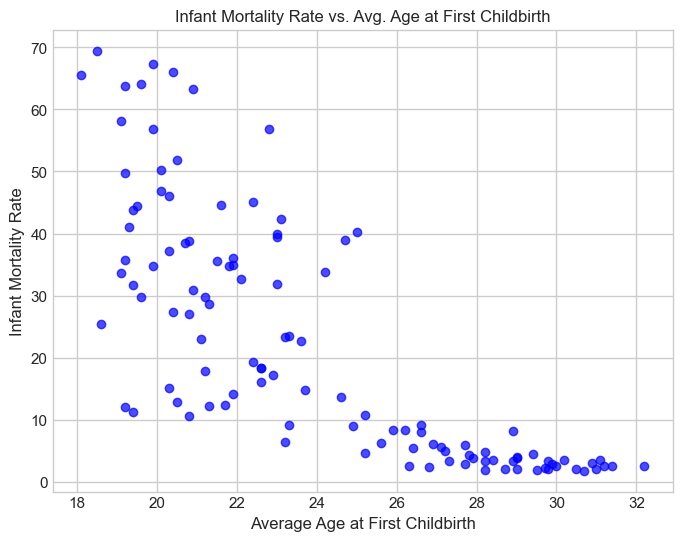

In [113]:
import matplotlib.pyplot as plt

# Drop rows with NaNs in relevant columns
df_clean = df_2019.dropna(subset=['infant_mortality_rate', 'maternal_mortality_ratio', 'average_first_child_age'])

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')

# Plot 1: Infant Mortality Rate vs. Average Age at First Childbirth
plt.figure(figsize=(8, 6))
plt.scatter(df_clean['average_first_child_age'], df_clean['infant_mortality_rate'], color='blue', alpha=0.7)
plt.xlabel('Average Age at First Childbirth')
plt.ylabel('Infant Mortality Rate')
plt.title('Infant Mortality Rate vs. Avg. Age at First Childbirth')
plt.grid(True)

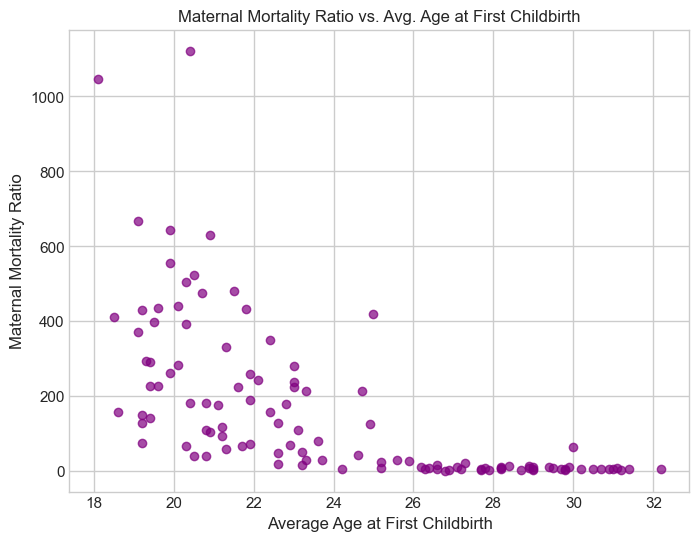

In [117]:
# Plot 2: Maternal Mortality Ratio vs. Average Age at First Childbirth
plt.figure(figsize=(8, 6))
plt.scatter(df_clean['average_first_child_age'], df_clean['maternal_mortality_ratio'], color='purple', alpha=0.7)
plt.xlabel('Average Age at First Childbirth')
plt.ylabel('Maternal Mortality Ratio')
plt.title('Maternal Mortality Ratio vs. Avg. Age at First Childbirth')
plt.grid(True)
plt.show()

In [120]:
# Calculate Pearson correlation coefficients
infant_corr = df_clean['infant_mortality_rate'].corr(df_clean['average_first_child_age'])
maternal_corr = df_clean['maternal_mortality_ratio'].corr(df_clean['average_first_child_age'])

print(f"Correlation (Infant Mortality vs. Age at First Child): {infant_corr:.3f}")
print(f"Correlation (Maternal Mortality vs. Age at First Child): {maternal_corr:.3f}")


Correlation (Infant Mortality vs. Age at First Child): -0.773
Correlation (Maternal Mortality vs. Age at First Child): -0.633


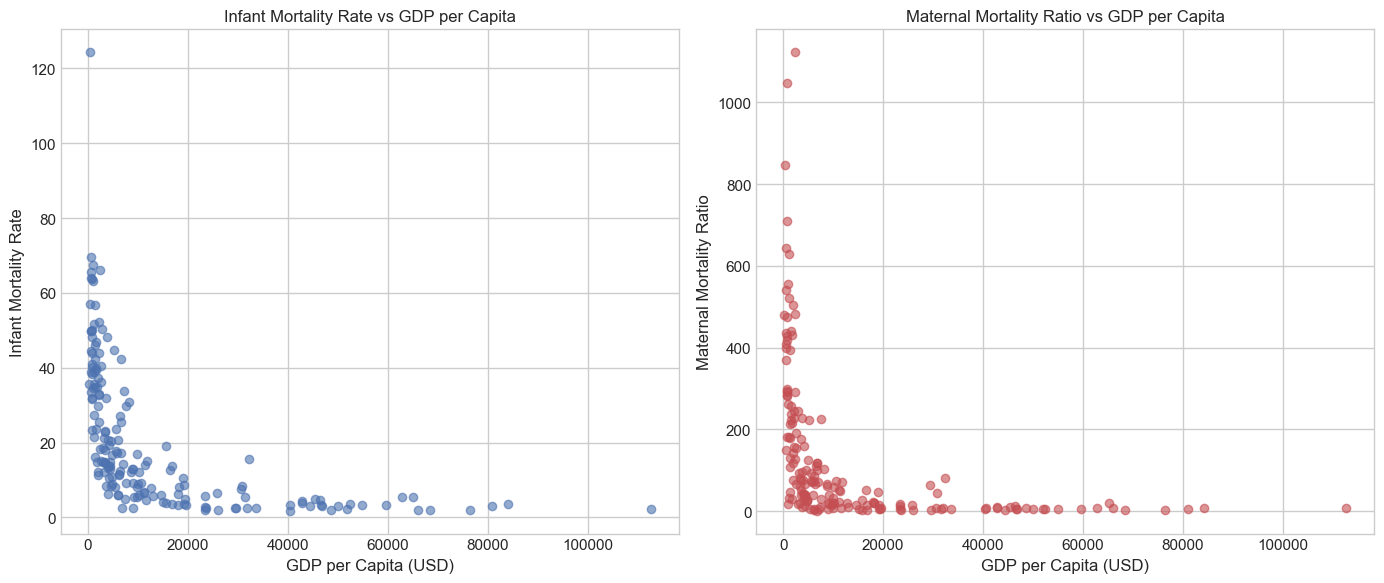

Correlation (Infant Mortality vs. GDP per Capita): -0.517
Correlation (Maternal Mortality vs. GDP per Capita): -0.397


In [121]:
import matplotlib.pyplot as plt

# Drop rows with NaNs for the relevant columns
df_corr = df_2019[['infant_mortality_rate', 'maternal_mortality_ratio', 'gdp_per_capita_(usd)']].dropna()

# Set up the figure and axes for the plots
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Infant Mortality vs GDP per Capita
axs[0].scatter(df_corr['gdp_per_capita_(usd)'], df_corr['infant_mortality_rate'], color='b', alpha=0.6)
axs[0].set_title('Infant Mortality Rate vs GDP per Capita')
axs[0].set_xlabel('GDP per Capita (USD)')
axs[0].set_ylabel('Infant Mortality Rate')
axs[0].grid(True)

# Plot for Maternal Mortality vs GDP per Capita
axs[1].scatter(df_corr['gdp_per_capita_(usd)'], df_corr['maternal_mortality_ratio'], color='r', alpha=0.6)
axs[1].set_title('Maternal Mortality Ratio vs GDP per Capita')
axs[1].set_xlabel('GDP per Capita (USD)')
axs[1].set_ylabel('Maternal Mortality Ratio')
axs[1].grid(True)

# Show the plots
plt.tight_layout()
plt.show()

# Calculate and print correlations
infant_gdp_corr = df_corr['infant_mortality_rate'].corr(df_corr['gdp_per_capita_(usd)'])
maternal_gdp_corr = df_corr['maternal_mortality_ratio'].corr(df_corr['gdp_per_capita_(usd)'])

print(f"Correlation (Infant Mortality vs. GDP per Capita): {infant_gdp_corr:.3f}")
print(f"Correlation (Maternal Mortality vs. GDP per Capita): {maternal_gdp_corr:.3f}")


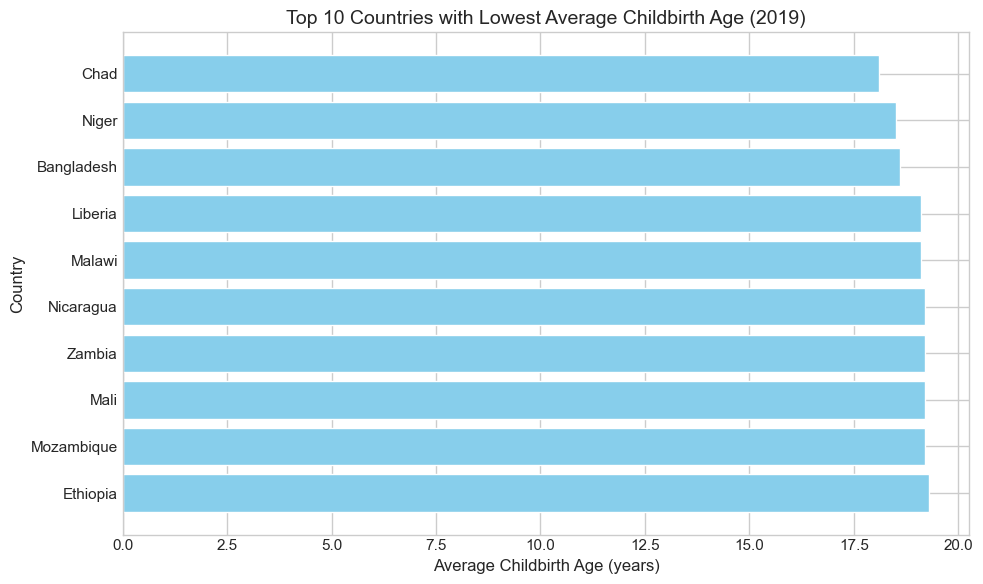

    Country Name  average_first_child_age
37          Chad                     18.1
135        Niger                     18.5
13    Bangladesh                     18.6
108      Liberia                     19.1
113       Malawi                     19.1
134    Nicaragua                     19.2
217       Zambia                     19.2
116         Mali                     19.2
128   Mozambique                     19.2
65      Ethiopia                     19.3


In [122]:
import pandas as pd
import matplotlib.pyplot as plt

# Sort the DataFrame by 'average_first_child_age' and select top 10 countries with the lowest values
top_10_lowest_childbirth = df_2019[['Country Name', 'average_first_child_age']].dropna().sort_values(by='average_first_child_age').head(10)

# Create a bar plot for the top 10 countries with the lowest average childbirth age
plt.figure(figsize=(10, 6))
plt.barh(top_10_lowest_childbirth['Country Name'], top_10_lowest_childbirth['average_first_child_age'], color='skyblue')

# Add titles and labels
plt.title('Top 10 Countries with Lowest Average Childbirth Age (2019)', fontsize=14)
plt.xlabel('Average Childbirth Age (years)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.gca().invert_yaxis()  # To show the highest values at the top

# Show the plot
plt.tight_layout()
plt.show()

# Optionally, display the full columns for the top 10 countries
print(top_10_lowest_childbirth)


<Figure size 1200x800 with 0 Axes>

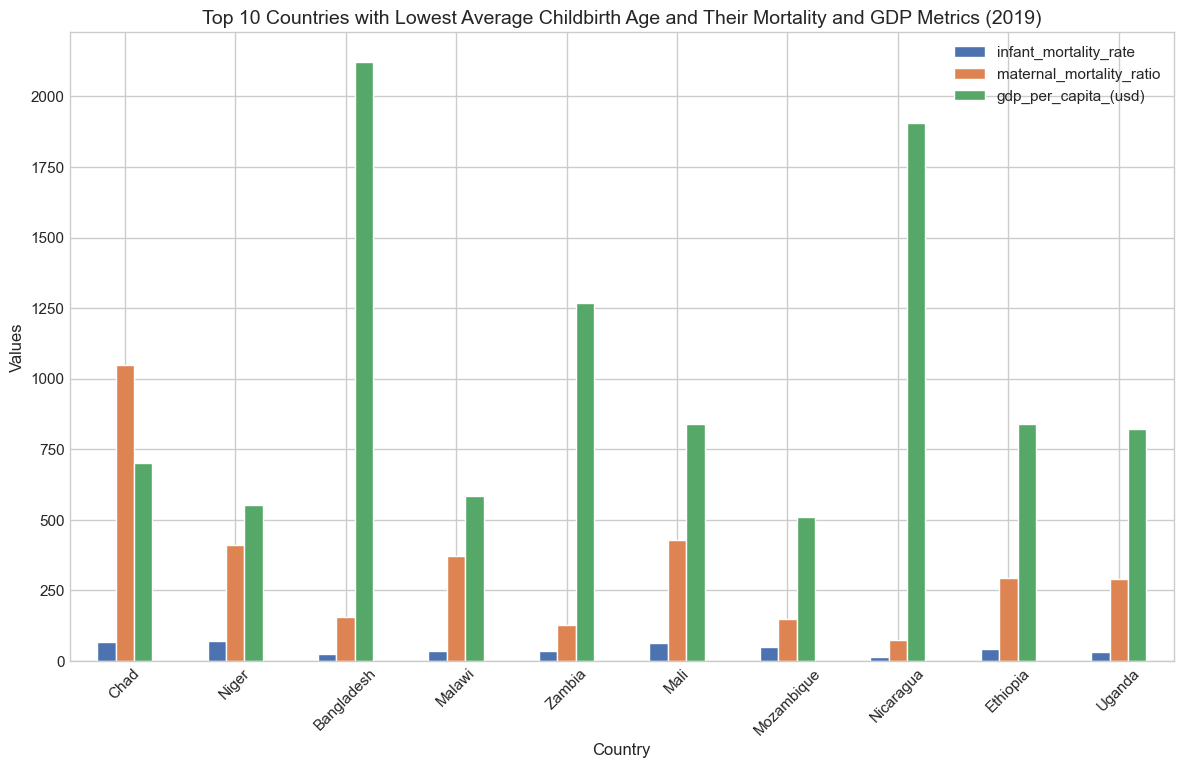

In [124]:
import pandas as pd
import matplotlib.pyplot as plt

# Sort the DataFrame by 'average_first_child_age' and select top 10 countries with the lowest values
top_10_lowest_childbirth = df_2019[['Country Name', 'average_first_child_age', 'infant_mortality_rate', 'maternal_mortality_ratio', 'gdp_per_capita_(usd)']].dropna().sort_values(by='average_first_child_age').head(10)

# Set the 'Country Name' as the index for easier plotting
top_10_lowest_childbirth.set_index('Country Name', inplace=True)

# Create a figure and set the size
plt.figure(figsize=(12, 8))

# Plotting the bar chart for each of the metrics
top_10_lowest_childbirth[['infant_mortality_rate', 'maternal_mortality_ratio', 'gdp_per_capita_(usd)']].plot(kind='bar', stacked=False, figsize=(12, 8))

# Add titles and labels
plt.title('Top 10 Countries with Lowest Average Childbirth Age and Their Mortality and GDP Metrics (2019)', fontsize=14)
plt.ylabel('Values', fontsize=12)
plt.xlabel('Country', fontsize=12)

# Display the plot
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()


/var/folders/sm/h_vm8nzd6z54q1s5kfsmm6x00000gn/T/ipykernel_37667/1731992556.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top_10_lowest_childbirth.index, rotation=45, ha='right')


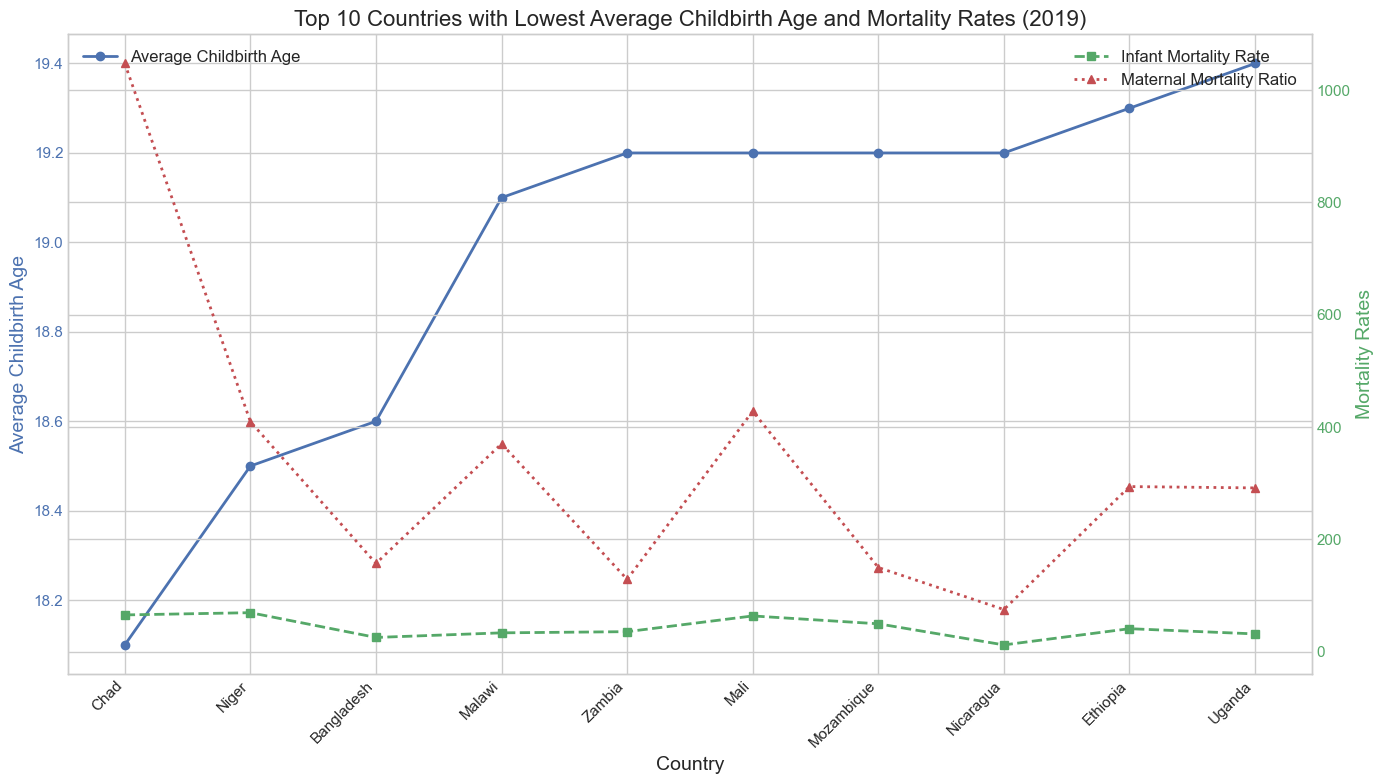

In [129]:
import pandas as pd
import matplotlib.pyplot as plt

# Sort the DataFrame by 'average_first_child_age' and select top 10 countries with the lowest values
top_10_lowest_childbirth = df_2019[['Country Name', 'average_first_child_age', 'infant_mortality_rate', 'maternal_mortality_ratio', 'gdp_per_capita_(usd)']].dropna().sort_values(by='average_first_child_age').head(10)

# Set the 'Country Name' as the index for easier plotting
top_10_lowest_childbirth.set_index('Country Name', inplace=True)

# Create a figure and set the size
fig, ax1 = plt.subplots(figsize=(14, 8))

# Plot the first line for average_first_child_age
ax1.plot(top_10_lowest_childbirth.index, top_10_lowest_childbirth['average_first_child_age'], label='Average Childbirth Age', color='b', marker='o', linestyle='-', linewidth=2)

# Set labels for the first y-axis
ax1.set_xlabel('Country', fontsize=14)
ax1.set_ylabel('Average Childbirth Age', fontsize=14, color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xticklabels(top_10_lowest_childbirth.index, rotation=45, ha='right')

# Create a secondary y-axis for infant_mortality_rate and maternal_mortality_ratio
ax2 = ax1.twinx()

# Plot the second line for infant_mortality_rate
ax2.plot(top_10_lowest_childbirth.index, top_10_lowest_childbirth['infant_mortality_rate'], label='Infant Mortality Rate', color='g', marker='s', linestyle='--', linewidth=2)

# Plot the third line for maternal_mortality_ratio
ax2.plot(top_10_lowest_childbirth.index, top_10_lowest_childbirth['maternal_mortality_ratio'], label='Maternal Mortality Ratio', color='r', marker='^', linestyle=':', linewidth=2)

# Set labels for the secondary y-axis
ax2.set_ylabel('Mortality Rates', fontsize=14, color='g')
ax2.tick_params(axis='y', labelcolor='g')

# Add legends for the lines
ax1.legend(loc='upper left', fontsize=12)
ax2.legend(loc='upper right', fontsize=12)

# Title and grid
ax1.set_title('Top 10 Countries with Lowest Average Childbirth Age and Mortality Rates (2019)', fontsize=16)
ax1.grid(True)

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


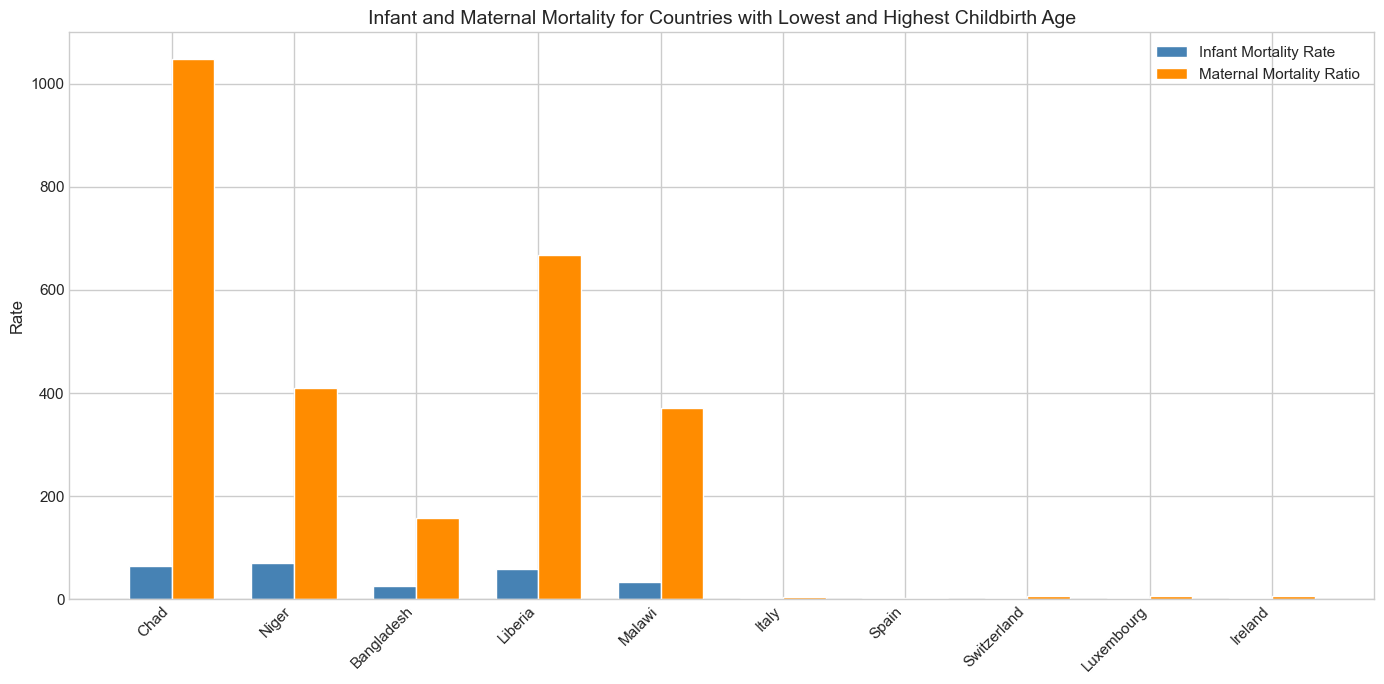

In [147]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filter out rows with NaNs in required columns
df_filtered = df_2019.dropna(subset=['average_first_child_age', 'infant_mortality_rate', 'maternal_mortality_ratio'])

# Get 5 countries with lowest and highest average childbirth age
lowest_age = df_filtered.nsmallest(5, 'average_first_child_age')
highest_age = df_filtered.nlargest(5, 'average_first_child_age')

# Combine for plotting
combined = pd.concat([lowest_age, highest_age])
labels = combined['Country Name'].values
infant = combined['infant_mortality_rate'].values
maternal = combined['maternal_mortality_ratio'].values

x = np.arange(len(labels))
width = 0.35

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.bar(x - width/2, infant, width, label='Infant Mortality Rate', color='steelblue')
bars2 = ax.bar(x + width/2, maternal, width, label='Maternal Mortality Ratio', color='darkorange')

# Labels and formatting
ax.set_title('Infant and Maternal Mortality for Countries with Lowest and Highest Childbirth Age', fontsize=14)
ax.set_ylabel('Rate', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()


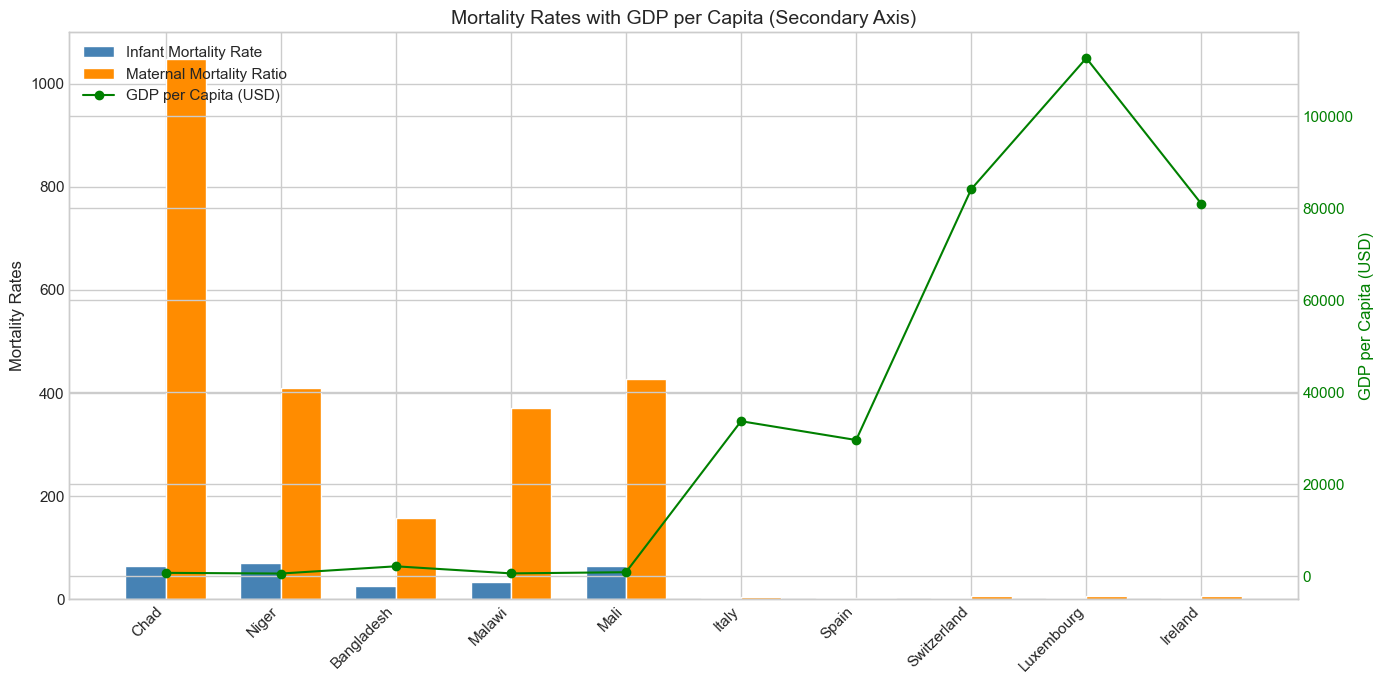

In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filter out rows with required columns
df_filtered = df_2019.dropna(subset=['average_first_child_age', 'infant_mortality_rate', 'maternal_mortality_ratio', 'gdp_per_capita_(usd)'])

# Get top 5 countries with lowest and highest average childbirth age
lowest_age = df_filtered.nsmallest(5, 'average_first_child_age')
highest_age = df_filtered.nlargest(5, 'average_first_child_age')

# Combine
combined = pd.concat([lowest_age, highest_age])
labels = combined['Country Name'].values
infant = combined['infant_mortality_rate'].values
maternal = combined['maternal_mortality_ratio'].values
gdp = combined['gdp_per_capita_(usd)'].values

x = np.arange(len(labels))
width = 0.35

# Plot
fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar plots (left y-axis)
bars1 = ax1.bar(x - width/2, infant, width, label='Infant Mortality Rate', color='steelblue')
bars2 = ax1.bar(x + width/2, maternal, width, label='Maternal Mortality Ratio', color='darkorange')
ax1.set_ylabel('Mortality Rates', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha='right')
ax1.set_title('Mortality Rates with GDP per Capita (Secondary Axis)', fontsize=14)

# Line plot (right y-axis)
ax2 = ax1.twinx()
line = ax2.plot(x, gdp, color='green', marker='o', label='GDP per Capita (USD)')
ax2.set_ylabel('GDP per Capita (USD)', color='green', fontsize=12)
ax2.tick_params(axis='y', labelcolor='green')

# Combine legends from both axes
lines_labels = [*ax1.get_legend_handles_labels()[0], *ax2.get_legend_handles_labels()[0]]
labels_combined = [*ax1.get_legend_handles_labels()[1], *ax2.get_legend_handles_labels()[1]]
ax1.legend(lines_labels, labels_combined, loc='upper left')

plt.tight_layout()
plt.show()
